# EE P595 Homework 3: Identifying Malicious URLs (PyTorch)

<span style="color:red">**Released Date: February 5, 2026**</span>  
<span style="color:red">**Due Date: February 22, 2026**</span>

Build a 1D CNN to classify malicious HTTP request URLs using N-gram embeddings.

**Key Concepts:** N-gram extraction, Co-occurrence matrix, TruncatedSVD, 1D CNN

**Teammate:** _(Name if applicable)_

In [1]:
# %pip install torch tqdm assertpy scikit-learn pandas matplotlib
%pip install assertpy

Note: you may need to restart the kernel to use updated packages.


## 1. Data Loading

In [2]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split

# Load WAF URLs dataset
df = pd.read_csv('./waf-urls.csv')
print(f'Dataset: {len(df)} URLs')

# Split: 60% train, 20% val, 20% test
urls_tv, urls_test, labels_tv, labels_test = train_test_split(
    df['url'], df['label'], test_size=0.2, random_state=12345)
urls_train, urls_vali, labels_train, labels_vali = train_test_split(
    urls_tv, labels_tv, test_size=0.25, random_state=12345)

print(f'Train: {len(urls_train)}, Val: {len(urls_vali)}, Test: {len(urls_test)}')

Dataset: 60547 URLs
Train: 36327, Val: 12110, Test: 12110


## 2. N-Gram Functions

In [3]:
from assertpy import assert_that
from tqdm import tqdm

def iter_ngrams(text, n, start_symbol='\x00', end_symbol='\x01'):
    """Generate N-grams with start/end padding."""
    ## [ TODO 1 ] Implement N-gram generation
    # - Pad (n-1) start_symbols before text
    # - Pad n end_symbols after text
    # - Return generator of N-grams

    l = len(text) + n
    text = (n-1)*start_symbol + text + n*end_symbol
    for i in range(l):
        yield text[i:i+n]
    
# Test
assert_that(list(iter_ngrams('/test', n=3))).is_equal_to([
    '\x00\x00/', '\x00/t', '/te', 'tes', 'est', 'st\x01', 't\x01\x01', '\x01\x01\x01'
])

In [4]:
def build_ngram_mapping(urls, n, rare_threshold=2):
    """Build bidirectional N-gram to index mapping."""
    ngram_count = {}
    
    print('Counting N-grams...')
    for url in tqdm(urls):
        for ngram in iter_ngrams(url, n):
            ## [ TODO 2.1 ] Count N-gram occurrences
            if ngram in ngram_count:
                ngram_count[ngram] += 1
            else:
                ngram_count[ngram] = 1
    
    n2i, i2n = {}, []
    n_rare = 0
    
    print('Building mapping...')
    for ngram, count in tqdm(ngram_count.items()):
        ## [ TODO 2.2 ] Build mapping (only if count >= rare_threshold)
        # - Add to n2i and i2n if frequent
        # - Track n_rare for rare N-grams
        if count < rare_threshold:
            continue

        n2i[ngram] = len(i2n)
        i2n.append(ngram)
    
    print(f'Unique: {len(ngram_count)}, Kept: {len(i2n)}')
    return n2i, i2n

# Test
n2i_test, i2n_test = build_ngram_mapping(['/x', '/xyz/23', '/233'], n=3)
assert_that(len(n2i_test)).is_equal_to(5)

Counting N-grams...


100%|██████████| 3/3 [00:00<00:00, 21472.55it/s]


Building mapping...


100%|██████████| 15/15 [00:00<00:00, 126081.28it/s]

Unique: 15, Kept: 5


## 3. Co-occurrence Matrix

In [5]:
from scipy.sparse import dok_matrix

def build_cooccurrence_matrix(urls, n, n2i_mapping, window_size):
    """Build normalized co-occurrence matrix."""
    n_ngram = len(n2i_mapping)
    unknown_idx = n_ngram
    co_matrix = dok_matrix((n_ngram+1, n_ngram+1))
    
    print(f'Building co-occurrence...')
    for url in tqdm(urls):
        prev_indices = []
        for ngram in iter_ngrams(url, n):
            ## [ TODO 3.1 ] Get N-gram index (unknown_idx if not found)
            if ngram in n2i_mapping:
                idx = n2i_mapping[ngram]
            else:
                idx = unknown_idx
            
            ## [ TODO 3.2 ] Update co-occurrence for prev neighbors in window
            if len(prev_indices) > window_size:
                window = prev_indices[-window_size:]
            else:
                window = prev_indices

            for prev_idx in window:
                co_matrix[idx, prev_idx] += 1
                co_matrix[prev_idx, idx] += 1
            
            prev_indices.append(idx)
    
    print('Normalizing...')
    row_sums = co_matrix.sum(axis=1)
    ## [ TODO 3.3 ] Normalize rows to probability distributions
    for (i, j) in tqdm(list(co_matrix.keys())):
        co_matrix[i, j] /= row_sums[i]
    
    return co_matrix

In [6]:
# Build N-gram mapping and co-occurrence matrix
N = 4
WINDOW_SIZE = 5

n2i_urls, i2n_urls = build_ngram_mapping(urls_train, N)
cooccurrence_urls = build_cooccurrence_matrix(urls_train, N, n2i_urls, WINDOW_SIZE)
print(f'Co-occurrence shape: {cooccurrence_urls.shape}')

Counting N-grams...


100%|██████████| 36327/36327 [00:01<00:00, 34938.88it/s]


Building mapping...


100%|██████████| 160195/160195 [00:00<00:00, 760021.95it/s]


Unique: 160195, Kept: 82844
Building co-occurrence...


100%|██████████| 36327/36327 [05:29<00:00, 110.23it/s]


Normalizing...


100%|██████████| 2542234/2542234 [00:34<00:00, 73424.91it/s]

Co-occurrence shape: (82845, 82845)


## 4. Embedding via TruncatedSVD

In [7]:
from sklearn.decomposition import TruncatedSVD

EMBEDDING_DIMS = 10

## [ TODO 4 ] Create TruncatedSVD and fit_transform co-occurrence matrix
svd = TruncatedSVD(n_components=EMBEDDING_DIMS, n_iter=20, random_state=42)
embedding_svd = svd.fit_transform(cooccurrence_urls)

assert embedding_svd.shape == (len(n2i_urls)+1, EMBEDDING_DIMS)

## 5. PyTorch Model

In [8]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Device: {device}')

Device: cuda


In [9]:
def transform_urls(urls, padded_len, n, n2i_mapping, pad_symbol='\x01'):
    """Convert URLs to N-gram index sequences."""
    batch = np.empty((len(urls), padded_len + n), dtype=int)
    unknown_idx = len(n2i_mapping)
    
    for i, url in enumerate(urls):
        ## [ TODO 5.1 ] Pad URL to padded_len
        padding_len = padded_len - len(url)
        url += padding_len*pad_symbol
        
        ## [ TODO 5.2 ] Convert N-grams to indices
        for j, ngram in enumerate(iter_ngrams(url, n)):
            if ngram in n2i_mapping:
                batch[i, j] = n2i_mapping[ngram]
            else:
                batch[i, j] = unknown_idx
    
    return batch

In [10]:
class URLDataset(Dataset):
    def __init__(self, urls, labels, padded_len, n, n2i_mapping):
        self.data = transform_urls(list(urls), padded_len, n, n2i_mapping)
        self.labels = labels.values.astype(np.float32)
    
    def __len__(self):
        return len(self.labels)
    
    def __getitem__(self, idx):
        return torch.tensor(self.data[idx], dtype=torch.long), torch.tensor(self.labels[idx])

In [91]:
class URLCNN(nn.Module):
    """1D CNN for URL classification."""
    def __init__(self, n_ngram, embedding_weights, dropout=0.25):
        super().__init__()
        embed_dim = embedding_weights.shape[1]
        
        ## [ TODO 6.1 ] Embedding layer (frozen, initialized with embedding_weights)
        self.embedding = nn.Embedding(
            num_embeddings=n_ngram + 1,
            embedding_dim=embed_dim, 
            _freeze=True, 
            _weight=torch.Tensor(embedding_weights)
        )

        ## [ TODO 6.2 ] Conv blocks
        # conv1: embed_dim -> 20, kernel=5, padding=2
        # conv2: 20 -> 40, kernel=5, padding=2
        # conv3: 40 -> 80, kernel=5, padding=2
        # pool1: MaxPool1d(2), pool2: MaxPool1d(5), pool3: MaxPool1d(5)
        self.conv1 = nn.Conv1d(
            in_channels=embed_dim,
            out_channels=20,
            kernel_size=5,
            padding=2
        )
        self.pool1 = nn.MaxPool1d(2)
        
        self.conv2 = nn.Conv1d(
            in_channels=20,
            out_channels=40,
            kernel_size=5,
            padding=2
        )
        self.pool2 = nn.MaxPool1d(5)

        self.conv3 = nn.Conv1d(
            in_channels=40,
            out_channels=80,
            kernel_size=5,
            padding=2
        )
        self.pool3 = nn.MaxPool1d(5)
        
        ## [ TODO 6.3 ] FC layers
        # fc1: 160 -> 16, fc2: 16 -> 1
        self.fc1 = nn.Linear(
            in_features=160,
            out_features=16)
        
        self.fc2 = nn.Linear(
            in_features=16,
            out_features=1
        )
    
    def forward(self, x):
        ## [ TODO 6.4 ] Forward pass
        # Embedding -> permute -> conv blocks -> flatten -> FC -> sigmoid

        x = self.embedding(x)

        x = torch.permute(x, (0, 2, 1))

        x = self.conv1(x)
        x = self.pool1(x)
        x = self.conv2(x)
        x = self.pool2(x)
        x = self.conv3(x)
        x = self.pool3(x)

        x = torch.flatten(x, 1)

        x = self.fc1(x)
        x = nn.ReLU()(x)
        x = self.fc2(x)

        x = nn.Sigmoid()(x)
        
        x = torch.squeeze(x, 1) # Remove extra dimension
        return x

In [92]:
# Hyperparameters
BATCH_SIZE = 256
MAX_URL_LEN = 96
N_EPOCHS = 10

# Create datasets
train_dataset = URLDataset(urls_train, labels_train, MAX_URL_LEN, N, n2i_urls)
val_dataset = URLDataset(urls_vali, labels_vali, MAX_URL_LEN, N, n2i_urls)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE)

model = URLCNN(len(n2i_urls), embedding_svd.astype(np.float32)).to(device)
criterion = nn.BCELoss()
optimizer = torch.optim.Adam(model.parameters())

In [93]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        ## [ TODO 7 ] Training step
        # optimizer.zero_grad(), forward, loss, backward, step
        optimizer.zero_grad()
        out = model.forward(x)
        loss = criterion(out, y)
        loss.backward()
        optimizer.step()

        total_loss += (loss.item() * len(y))
        correct += ((out > 0.5) == y).sum().item()
        total += len(y)

    return total_loss / total, correct / total

def evaluate(model, loader, criterion):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    with torch.no_grad():
        for x, y in loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            total_loss += criterion(out, y).item() * len(y)
            correct += ((out > 0.5) == y).sum().item()
            total += len(y)
    return total_loss / total, correct / total

In [94]:
# Training loop
history = {'loss': [], 'acc': [], 'val_loss': [], 'val_acc': []}

for epoch in range(N_EPOCHS):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = evaluate(model, val_loader, criterion)
    history['loss'].append(train_loss)
    history['acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    print(f'Epoch {epoch+1}: Train Acc={train_acc:.4f}, Val Acc={val_acc:.4f}')

torch.save(model.state_dict(), './model-url-cnn.pt')

Epoch 1: Train Acc=0.7387, Val Acc=0.8958
Epoch 2: Train Acc=0.9087, Val Acc=0.9222
Epoch 3: Train Acc=0.9193, Val Acc=0.9154
Epoch 4: Train Acc=0.9258, Val Acc=0.9324
Epoch 5: Train Acc=0.9264, Val Acc=0.9213
Epoch 6: Train Acc=0.9341, Val Acc=0.9238
Epoch 7: Train Acc=0.9370, Val Acc=0.9398
Epoch 8: Train Acc=0.9381, Val Acc=0.9399
Epoch 9: Train Acc=0.9405, Val Acc=0.9433
Epoch 10: Train Acc=0.9430, Val Acc=0.9445


## 6. Evaluation

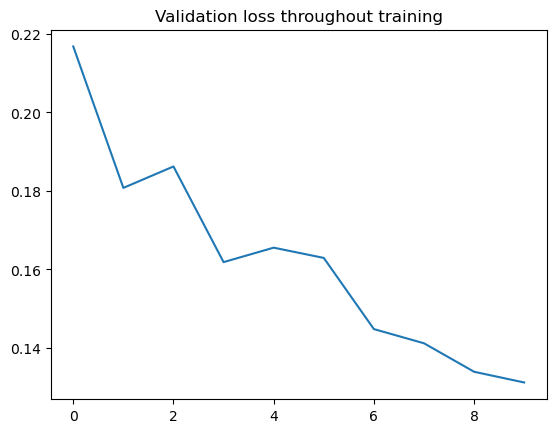

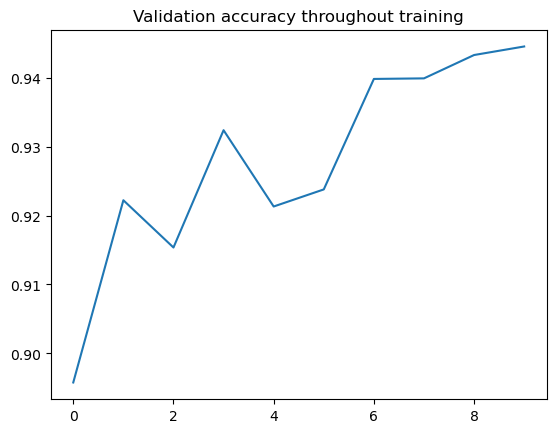

In [97]:
import matplotlib.pyplot as plt

## [ TODO 8 ] Plot loss and accuracy curves
plt.plot(history['val_loss'])
plt.title('Validation loss throughout training')
plt.show()

plt.plot(history['val_acc'])
plt.title('Validation accuracy throughout training')
plt.show()

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

## [ TODO 9 ] Test evaluation
# - Create test dataset and loader
# - Predict and collect results
# - Print confusion matrix and classification report

test_dataset = URLDataset(urls_test, labels_test, MAX_URL_LEN, N, n2i_urls)
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE)

test_total_loss, test_total = 0, 0, 0
test_cm = np.zeros((2,2))

test_y = np.asarray([])
test_y_pred = np.asarray([])

model.eval()
with torch.no_grad():
    for x, y in test_loader:
        out = model(x.to(device)).cpu()
        y_pred = (out > 0.5)
        test_total_loss += criterion(out, y).item() * len(y)
        test_correct += ((out > 0.5) == y).sum().item()
        test_total += len(y)

        cm += confusion_matrix(y, y_pred)

        test_y = np.hstack([y, test_y])
        test_y_pred = np.hstack([y_pred, test_y_pred])

test_loss = test_total_loss / test_total
test_acc = np.mean(test_y_pred == test_y)

print('Test loss:', test_loss),
print('Test accuracy', test_acc),
print()
print('Confusion matrix:')
print(confusion_matrix(test_y, test_y_pred))
print()
print('Classification report:')
print(classification_report(test_y, test_y_pred))

Test loss: 0.1399015867825779
Test accuracy 0.9440132122213047

Confusion matrix:
[[6753  390]
 [ 288 4679]]

Classification report:
              precision    recall  f1-score   support

         0.0       0.96      0.95      0.95      7143
         1.0       0.92      0.94      0.93      4967

    accuracy                           0.94     12110
   macro avg       0.94      0.94      0.94     12110
weighted avg       0.94      0.94      0.94     12110



## Questions

**Q1: Analyze model performance. Does lower loss indicate higher accuracy?** (2 pts)


**Your Answer:**

In general, lower loss does indicate higher accuracy since misclassification both increases loss and decreases accuracy. However, they are not identical or homomorphic. In part, this is because accuracy depends on the discrete predictions (best guess y-value) while BCE is sensitive to the logits as continuous values (indicating a level of confidence in one y-value or the other). They may also have different responses to unbalanced data, although this is not a major issue here since the classes are fairly balanced.


**Q2: Is large window_size (e.g., 50) good? Other compression methods?** (2 pts)

**Your Answer:**

Probably not. The correlation matrix is sensitive to which n-grams fall within the window size of one another, so any other information about how close they are is lost. The information that two n-grams are very close together is more likely to be relevant than the fact that they appear in the same half of a URL somewhere (since there are many more combinations of the latter that occur by random chance), so a shorter distance helps the embedding to retain useful information rather than noise while reducing dimensionality. A larger window size also significantly increases preprocessing time (for this lab model training took no more than a minute, preprocessing with WL=5 about 3-5 minutes, and when I accidentally used the whole URL as the window it took >30 minutes).

## Submission
Submit: `homework-3-student-20260205.ipynb` + `model-url-cnn.pt`